In [2]:
# All required imports to run this file are stored here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Read in the relevant csv files, store them as pd dataframes
all_vuln_df = pd.read_csv("../data/checklist_data_cleaned.csv")
covered_vuln_df = pd.read_csv("../data/specific_data_cleaned.csv")

# Display them both to check
display(all_vuln_df)
display(covered_vuln_df)

,Category,Vulnerability
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...
2,STORAGE,MASWE-0003: Backup Unencrypted
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...
...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...


,App Name,MASVS Category,Vulnerability,MASVS Counterpart
0,Androgoat,Storage,Insecure Data Storage – Shared Prefs - 1,MASWE-0006: Sensitive Data Stored Unencrypted ...
1,Androgoat,Storage,Insecure Data Storage - Shared Prefs - 2,MASWE-0006: Sensitive Data Stored Unencrypted ...
2,Androgoat,Storage,Insecure Data Storage - SQLite,MASWE-0006: Sensitive Data Stored Unencrypted ...
3,Androgoat,Storage,Insecure Data Storage – Temp Files,MASWE-0006: Sensitive Data Stored Unencrypted ...
4,Androgoat,Storage,Insecure Data Storage – SD Card,MASWE-0007: Sensitive Data Stored Unencrypted ...
...,...,...,...,...
158,BugBazaar,Code,Runtime code modification,MASWE-0085: Unsafe Dynamic Code Loading
159,BugBazaar,Code,Improper cache handling,MASWE-0082 Unsafe Handling of Data from Local ...
160,BugBazaar,Resilience,Passcode Bypass,MASWE-0008: Missing Device Secure Lock Verific...
161,BugBazaar,Resilience,Debuggable application,MASWE-0067: Debuggable Flag Not Disabled


In [4]:
# --- Count coverage frequency ---
coverage_count = (
    covered_vuln_df.groupby("MASVS Counterpart")
    .size()
    .reset_index(name="Coverage Count")
)

In [5]:
# --- Merge to see which ones are covered and how often ---
merged_df = all_vuln_df.merge(
    coverage_count,
    left_on="Vulnerability",
    right_on="MASVS Counterpart",
    how="left"
)

display(merged_df)

display(merged_df[merged_df["Coverage Count"] == 1])

,Category,Vulnerability,MASVS Counterpart,Coverage Count
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7.0
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,NaN
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,3.0
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,NaN
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,14.0
...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,NaN
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,NaN
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,NaN
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,NaN


,Category,Vulnerability,MASVS Counterpart,Coverage Count
10,CRYPTO,MASWE-0013: Hardcoded Cryptographic Keys in Use,MASWE-0013: Hardcoded Cryptographic Keys in Use,1.0
11,CRYPTO,MASWE-0014: Cryptographic Keys Not Properly Pr...,MASWE-0014: Cryptographic Keys Not Properly Pr...,1.0
16,CRYPTO,MASWE-0019: Risky Cryptography Implementations,MASWE-0019: Risky Cryptography Implementations,1.0
45,NETWORK,MASWE-0047: Insecure Identity Pinning,MASWE-0047: Insecure Identity Pinning,1.0
54,PLATFORM,MASWE-0056: Tapjacking Attacks,MASWE-0056: Tapjacking Attacks,1.0
55,PLATFORM,MASWE-0057: StrandHogg Attack / Task Affinity ...,MASWE-0057: StrandHogg Attack / Task Affinity ...,1.0
58,PLATFORM,MASWE-0060: Insecure Use of UIActivity,MASWE-0060: Insecure Use of UIActivity,1.0
66,PLATFORM,MASWE-0068: JavaScript Bridges in WebViews,MASWE-0068: JavaScript Bridges in WebViews,1.0
71,PLATFORM,MASWE-0073: Insecure WebResourceResponse Imple...,MASWE-0073: Insecure WebResourceResponse Imple...,1.0
81,CODE,MASWE-0083: Unsafe Handling of Data From The U...,MASWE-0083: Unsafe Handling of Data From The U...,1.0


In [6]:
# Fill NaN (means no coverage) with 0
merged_df["Coverage Count"] = merged_df["Coverage Count"].fillna(0).astype(int)

# --- Identify uncovered vulnerabilities ---
uncovered = merged_df[merged_df["Coverage Count"] == 0]

# --- Print results ---
print("=== Coverage summary ===")
print(merged_df[["Vulnerability", "Coverage Count"]])

print("\n=== Uncovered vulnerabilities ===")
print(uncovered["Vulnerability"])

=== Coverage summary ===
                                         Vulnerability  Coverage Count
0    MASWE-0001: Insertion of Sensitive Data into Logs               7
1    MASWE-0002: Sensitive Data Stored With Insuffi...               0
2                       MASWE-0003: Backup Unencrypted               3
3    MASWE-0004: Sensitive Data Not Excluded From B...               0
4    MASWE-0006: Sensitive Data Stored Unencrypted ...              14
..                                                 ...             ...
112  MASWE-0112: Inadequate Data Collection Declara...               0
113  MASWE-0113: Lack of Proper Data Management Con...               0
114    MASWE-0114: Inadequate Data Visibility Controls               0
115  MASWE-0115: Inadequate or Ambiguous User Conse...               0
116       MASWE-0117: Inadequate Permission Management               0

[117 rows x 2 columns]

=== Uncovered vulnerabilities ===
1      MASWE-0002: Sensitive Data Stored With Insuffi...
3      

In [7]:
# --- Filter only covered vulnerabilities ---
covered_only = merged_df[merged_df["Coverage Count"] > 0]

# --- Sort by coverage count (descending) ---
covered_sorted = covered_only.sort_values(by="Coverage Count", ascending=False)

# --- Display result ---
print("=== Covered vulnerabilities (sorted by coverage count) ===")
print(covered_sorted[["Vulnerability", "Coverage Count"]])
print("There are:", len(covered_sorted[["Vulnerability", "Coverage Count"]]), "covered vulnerabilities.")

=== Covered vulnerabilities (sorted by coverage count) ===
                                         Vulnerability  Coverage Count
64                        MASWE-0066: Insecure Intents              18
4    MASWE-0006: Sensitive Data Stored Unencrypted ...              14
62              MASWE-0064: Insecure Content Providers               9
56                     MASWE-0058: Insecure Deep Links               7
61            MASWE-0063: Insecure Broadcast Receivers               7
0    MASWE-0001: Insertion of Sensitive Data into Logs               7
5    MASWE-0007: Sensitive Data Stored Unencrypted ...               7
25   MASWE-0005: API Keys Hardcoded in the App Package               6
84                           MASWE-0086: SQL Injection               6
51   MASWE-0053: Sensitive Data Leaked via the User...               6
83             MASWE-0085: Unsafe Dynamic Code Loading               6
31   MASWE-0033: Authentication or Authorization Pr...               5
69   MASWE-0071: W

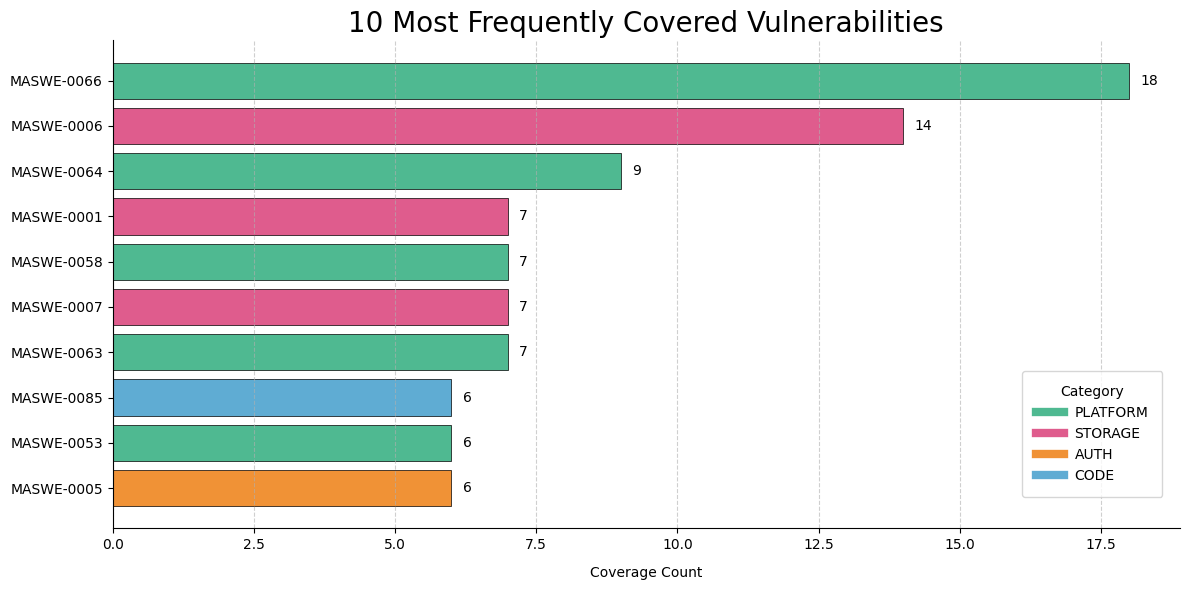

In [19]:
# PLOT 10 MOST FREQUENTLY COVERED VULNERABILITIES, COLOR THEM ACCORDING TO THEIR MASWE CATEGORY
# Filter out rows with NaN coverage count
df_filtered = merged_df.dropna(subset=["Coverage Count"])

# Sort by Coverage Count descending and take top 10
top10 = df_filtered.sort_values("Coverage Count", ascending=False).head(10)

# Keep only the MASWE-xxxx part of the Vulnerability column
top10["MASWE_Code"] = top10["Vulnerability"].str.extract(r"(MASWE-\d{4})")

# Define your custom colors for each category
category_colors = {
    "STORAGE": "#df5c8d",
    "CRYPTO": "#f65928",
    "AUTH": "#f09236",
    "NETWORK": "#f2c200",
    "PLATFORM": "#4fb991",
    "CODE": "#5facd3",
    "RESILIENCE": "#317cc0",
    "PRIVACY": "#8b5f9e"
}

# Map colors to each row based on category
bar_colors = top10["Category"].map(category_colors)

# Explicit-style horizontal bar plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10["MASWE_Code"], top10["Coverage Count"], color=bar_colors, 
               edgecolor="black", linewidth=0.5)
ax.set_xlabel("Coverage Count", fontsize=10, labelpad=10)
ax.set_title("10 Most Frequently Covered Vulnerabilities", fontsize=20)
ax.invert_yaxis()  # highest counts on top
ax.grid(axis="x", linestyle="--", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)


# Annotate each bar with its value
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2, str(int(width)),
            va='center', ha='left', fontsize=10)

# Create legend manually from custom colors
selected_categories = ["PLATFORM", "STORAGE", "AUTH", "CODE"]
handles = [plt.Line2D([0], [0], color=category_colors[cat], lw=6) for cat in selected_categories]
ax.legend(handles, selected_categories, title="Category", bbox_to_anchor=(0.99, 0.05), loc="lower right",
          borderpad=1)   # space between legend and axes (default 0.5))

plt.tight_layout()
plt.show()

# Save the figure
#fig.savefig("../plots/total_coverage_without_my_app/top_10_vulnerabilities", dpi=300, bbox_inches="tight")

In [9]:
# mark which vulnerabilities are covered
merged_df["Is_Covered"] = merged_df["Coverage Count"] > 0

display(merged_df)

# group by Category and count totals and covered ones
summary = merged_df.groupby("Category").agg(
    total_vulnerabilities=("Vulnerability", "count"),
    covered_vulnerabilities=("Is_Covered", "sum")
)

# optionally, add a coverage percentage
summary["coverage_percentage"] = (
    summary["covered_vulnerabilities"] / summary["total_vulnerabilities"] * 100
).round(1)

# Define the order to reflect maswe order
desired_order = ["STORAGE", "CRYPTO", "AUTH", "NETWORK", "PLATFORM", "CODE", "RESILIENCE", "PRIVACY"]

# Reindex summary
summary = summary.reindex(desired_order)

print(summary)

,Category,Vulnerability,MASVS Counterpart,Coverage Count,Is_Covered
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7,True
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,NaN,0,False
2,STORAGE,MASWE-0003: Backup Unencrypted,MASWE-0003: Backup Unencrypted,3,True
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,0,False
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,14,True
...,...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,0,False
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,0,False
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,0,False
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,0,False


            total_vulnerabilities  covered_vulnerabilities  \
Category                                                     
STORAGE                         6                        4   
CRYPTO                         19                        4   
AUTH                           20                        2   
NETWORK                         6                        3   
PLATFORM                       22                       16   
CODE                           15                        6   
RESILIENCE                     20                        7   
PRIVACY                         9                        0   

            coverage_percentage  
Category                         
STORAGE                    66.7  
CRYPTO                     21.1  
AUTH                       10.0  
NETWORK                    50.0  
PLATFORM                   72.7  
CODE                       40.0  
RESILIENCE                 35.0  
PRIVACY                     0.0  


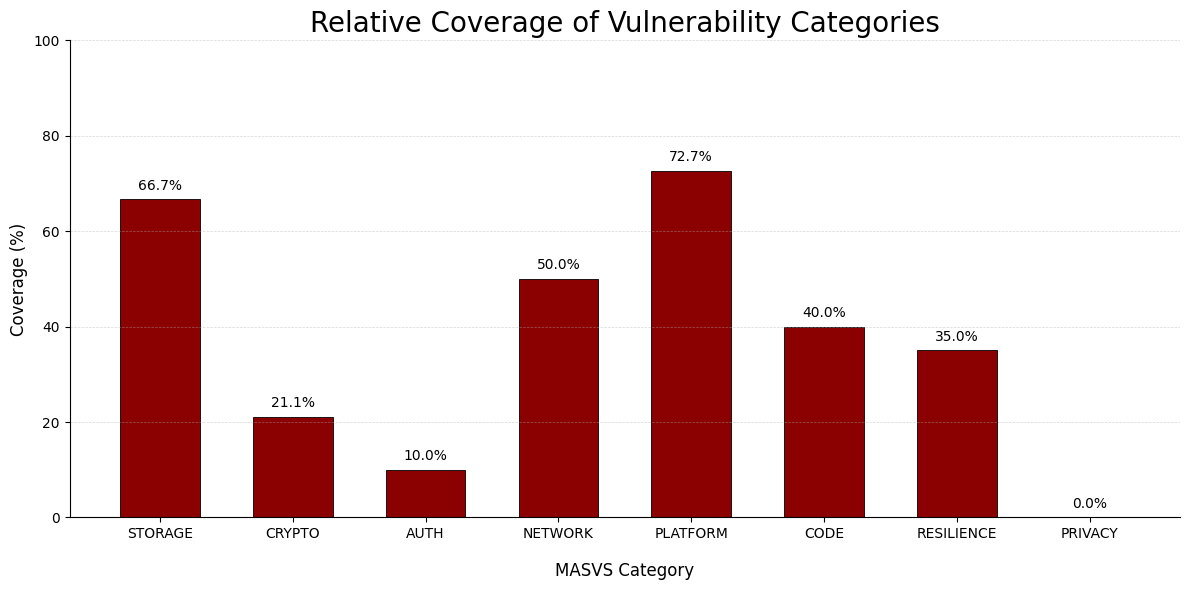

In [21]:
# Explicit style
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the bar chart
ax.bar(summary.index, summary["coverage_percentage"], color="darkred", 
       width=0.6, edgecolor="black", linewidth=0.6)

# Customize appearance
ax.set_title("Relative Coverage of Vulnerability Categories", fontsize=20)
ax.set_xlabel("MASVS Category", fontsize=12, labelpad=15)
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.5, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Add values on top of each bar
for i, v in enumerate(summary["coverage_percentage"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

# Save the figure
#fig.savefig("../plots/total_coverage_without_my_app/vulnerability_coverage_percentage", dpi=300, bbox_inches="tight")

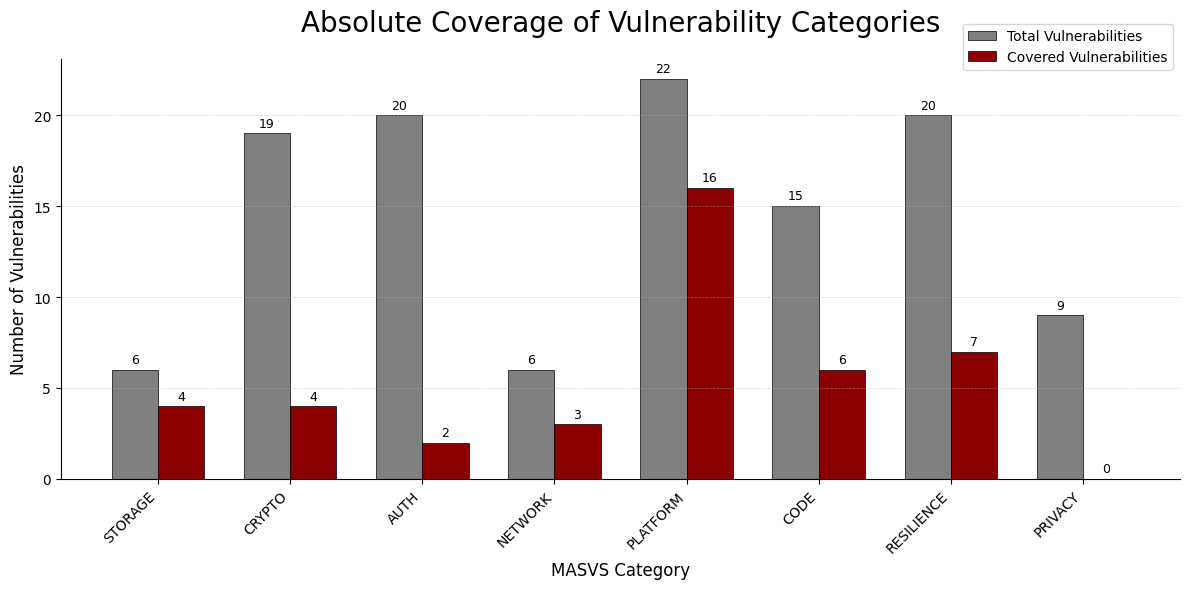

In [18]:
# Prepare data
categories = summary.index
total = summary["total_vulnerabilities"]
covered = summary["covered_vulnerabilities"]

# Set bar positions
x = np.arange(len(categories))
width = 0.35  # width of each bar

# Explicit style plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot both total and covered bars
bars1 = ax.bar(x - width/2, total, width, label="Total Vulnerabilities", color="gray",
               edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, covered, width, label="Covered Vulnerabilities", color="darkred",
               edgecolor="black", linewidth=0.5)

# Customize plot
ax.set_title("Absolute Coverage of Vulnerability Categories", fontsize=20, pad=20)
ax.set_xlabel("MASVS Category", fontsize=12)
ax.set_ylabel("Number of Vulnerabilities", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.legend(
    loc="upper right",          # position relative to the Axes
    bbox_to_anchor=(1, 1.1),  # (x, y) — 1.15 moves it a bit above the top
    frameon=True                # optional: remove box background
)
ax.grid(axis="y", linestyle="--", alpha=0.5, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Annotate bars with values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                f"{int(height)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Save the figure
#fig.savefig("../plots/total_coverage_without_my_app/total_vs_implemented_coverage_counts", dpi=300, bbox_inches="tight")